# Case 2: Institutional Comparison

In this practical case, we will consult the acts published in a specific year (for example, 2025) and group the number of acts issued by each institution (Commission, Council, European Parliament, etc.).

In [7]:
from bulletin.eurlex.api.client import EurlexBulletinClient

client = EurlexBulletinClient()

date_start = "2025-01-01"
date_end = "2025-12-31"

print(f"Downloading acts from {date_start} to {date_end}...")
acts_csv = client.get_acts_csv(date=date_start, date_end=date_end, language="ENG")


### Graphical representation of the number of acts issued by institution (top 20, 2025)



C:\Users\Usuario\AppData\Local\Temp\ipykernel_56160\3139817430.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=institution_counts, y='institution_label', x='count', palette='viridis')


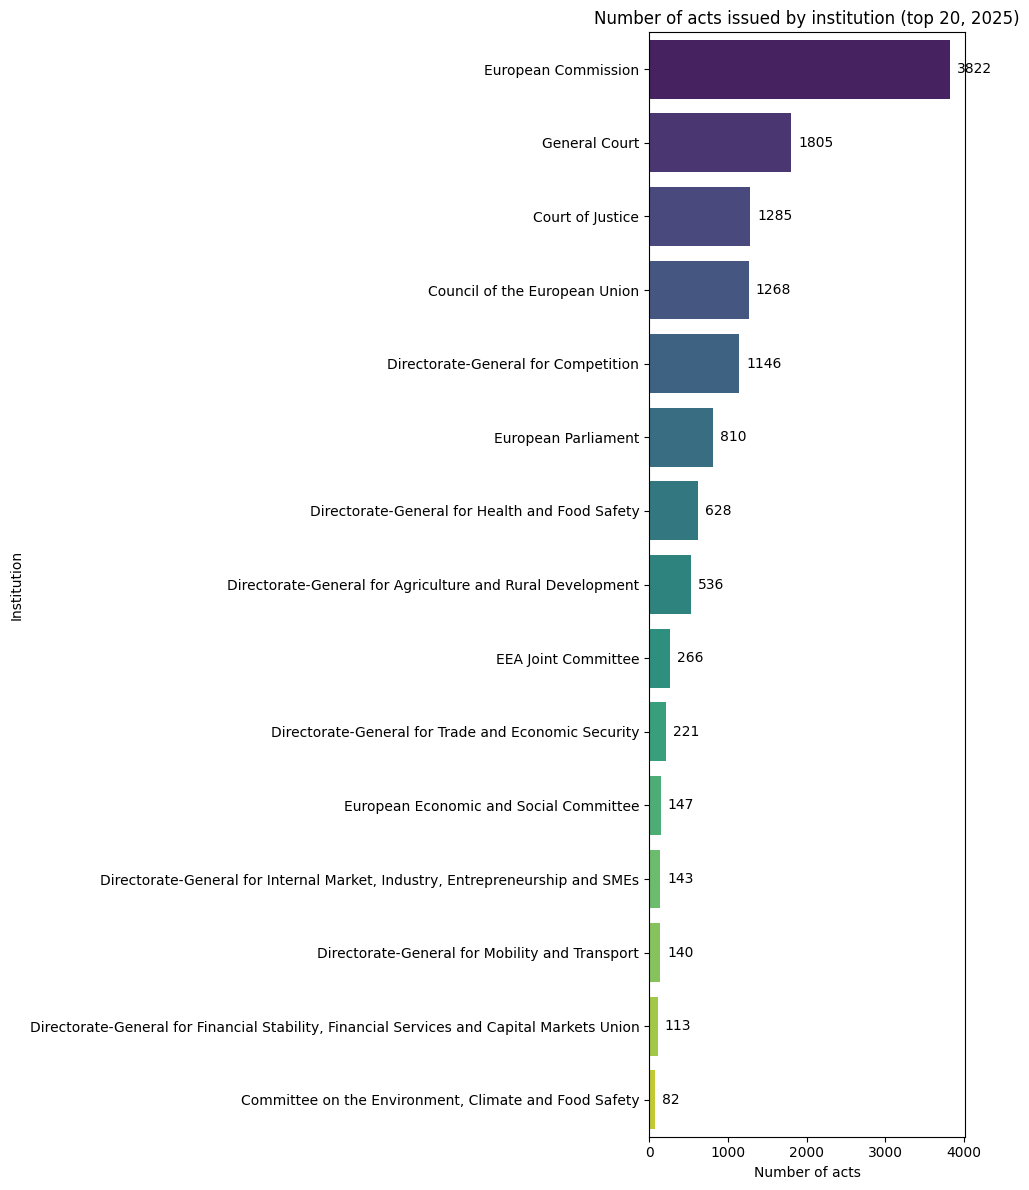

In [23]:
import pandas as pd
from io import StringIO

acts_df = pd.read_csv(StringIO(acts_csv))

import matplotlib.pyplot as plt
import seaborn as sns

institution_counts = acts_df['institution_label'].value_counts().nlargest(15).reset_index()
institution_counts.columns = ['institution_label', 'count']

institution_counts = institution_counts.sort_values('count', ascending=False)
plt.figure(figsize=(10, 12))
ax = sns.barplot(data=institution_counts, y='institution_label', x='count', palette='viridis')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width)}", xy=(width, p.get_y() + p.get_height() / 2), xytext=(5, 0), textcoords='offset points', ha='left', va='center')
plt.title('Number of acts issued by institution (top 20, 2025)')
plt.xlabel('Number of acts')
plt.ylabel('Institution')
plt.tight_layout()
plt.show()
